# Building Your First LangGraph

Now that we understand the building blocks, let's put them into practice by building our first functional graph. We'll implement Alfred's email processing system, where he needs to:

1. Read incoming emails
2. Classify them as spam or legitimate
3. Draft a preliminary response for legitimate emails
4. Send information to Mr. Wayne when legitimate (printing only)

This example demonstrates how to structure a workflow with LangGraph that involves LLM-based decision-making. While this can't be considered an Agent as no tool is involved, this section focuses more on learning the LangGraph framework than Agents.

## Setting Up Our Environment

First, let's install the required packages:

In [3]:
!pip install langgraph langchain_huggingface langchain-anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.7/627.7 kB 3.7 MB/s  0:00:00
  Attempting uninstall: anthropic
    Found existing installation: anthropic 0.84.0
    Uninstalling anthropic-0.84.0:
      Successfully uninstalled anthropic-0.84.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain-anthropic]ngchain-anthropic]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Next, let's import the necessary modules:

In [4]:
import os
from typing import TypedDict, List, Dict, Any, Optional
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage

In [8]:
import anthropic
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env", override=True)
api_key=os.environ.get("ANTHROPIC_API_KEY")

## Step 1: Define Our State

Let's define what information Alfred needs to track during the email processing workflow:

In [9]:
class EmailState(TypedDict):
    # The email being processed
    email: Dict[str, Any]  # Contains subject, sender, body, etc.

    # Category of the email (inquiry, complaint, etc.)
    email_category: Optional[str]

    # Reason why the email was marked as spam
    spam_reason: Optional[str]

    # Analysis and decisions
    is_spam: Optional[bool]
    
    # Response generation
    email_draft: Optional[str]
    
    # Processing metadata
    messages: List[Dict[str, Any]]  # Track conversation with LLM for analysis

> 💡 **Tip:** Make your state comprehensive enough to track all the important information, but avoid bloating it with unnecessary details.

## Step 2: Define Our Nodes

Now, let's create the processing functions that will form our nodes:

In [10]:
# Initialize our LLM
model = ChatAnthropic(model="claude-sonnet-4-20250514", temperature=0)

def read_email(state: EmailState):
    """Alfred reads and logs the incoming email"""
    email = state["email"]
    
    # Here we might do some initial preprocessing
    print(f"Alfred is processing an email from {email['sender']} with subject: {email['subject']}")
    
    # No state changes needed here
    return {}

def classify_email(state: EmailState):
    """Alfred uses an LLM to determine if the email is spam or legitimate"""
    email = state["email"]
    
    # Prepare our prompt for the LLM
    prompt = f"""
    As Alfred the butler, analyze this email and determine if it is spam or legitimate.
    
    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}
    
    First, determine if this email is spam. If it is spam, explain why.
    If it is legitimate, categorize it (inquiry, complaint, thank you, etc.).
    """
    
    # Call the LLM
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    
    # Simple logic to parse the response (in a real app, you'd want more robust parsing)
    response_text = response.content.lower()
    is_spam = "spam" in response_text and "not spam" not in response_text
    
    # Extract a reason if it's spam
    spam_reason = None
    if is_spam and "reason:" in response_text:
        spam_reason = response_text.split("reason:")[1].strip()
    
    # Determine category if legitimate
    email_category = None
    if not is_spam:
        categories = ["inquiry", "complaint", "thank you", "request", "information"]
        for category in categories:
            if category in response_text:
                email_category = category
                break
    
    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    
    # Return state updates
    return {
        "is_spam": is_spam,
        "spam_reason": spam_reason,
        "email_category": email_category,
        "messages": new_messages
    }

def handle_spam(state: EmailState):
    """Alfred discards spam email with a note"""
    print(f"Alfred has marked the email as spam. Reason: {state['spam_reason']}")
    print("The email has been moved to the spam folder.")
    
    # We're done processing this email
    return {}

def draft_response(state: EmailState):
    """Alfred drafts a preliminary response for legitimate emails"""
    email = state["email"]
    category = state["email_category"] or "general"
    
    # Prepare our prompt for the LLM
    prompt = f"""
    As Alfred the butler, draft a polite preliminary response to this email.
    
    Email:
    From: {email['sender']}
    Subject: {email['subject']}
    Body: {email['body']}
    
    This email has been categorized as: {category}
    
    Draft a brief, professional response that Mr. Hugg can review and personalize before sending.
    """
    
    # Call the LLM
    messages = [HumanMessage(content=prompt)]
    response = model.invoke(messages)
    
    # Update messages for tracking
    new_messages = state.get("messages", []) + [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": response.content}
    ]
    
    # Return state updates
    return {
        "email_draft": response.content,
        "messages": new_messages
    }

def notify_mr_hugg(state: EmailState):
    """Alfred notifies Mr. Hugg about the email and presents the draft response"""
    email = state["email"]
    
    print("\n" + "="*50)
    print(f"Sir, you've received an email from {email['sender']}.")
    print(f"Subject: {email['subject']}")
    print(f"Category: {state['email_category']}")
    print("\nI've prepared a draft response for your review:")
    print("-"*50)
    print(state["email_draft"])
    print("="*50 + "\n")
    
    # We're done processing this email
    return {}

## Step 3: Define Our Routing Logic

We need a function to determine which path to take after classification:

In [11]:
def route_email(state: EmailState) -> str:
    """Determine the next step based on spam classification"""
    if state["is_spam"]:
        return "spam"
    else:
        return "legitimate"

> 💡 **Note:** This routing function is called by LangGraph to determine which edge to follow after the classification node. The return value must match one of the keys in our conditional edges mapping.

## Step 4: Create the StateGraph and Define Edges

Now we connect everything together:

In [13]:
# Create the graph
email_graph = StateGraph(EmailState)

# Add nodes
email_graph.add_node("read_email", read_email)
email_graph.add_node("classify_email", classify_email)
email_graph.add_node("handle_spam", handle_spam)
email_graph.add_node("draft_response", draft_response)
email_graph.add_node("notify_mr_hugg", notify_mr_hugg)

# Start the edges
email_graph.add_edge(START, "read_email")
# Add edges - defining the flow
email_graph.add_edge("read_email", "classify_email")

# Add conditional branching from classify_email
email_graph.add_conditional_edges(
    "classify_email",
    route_email,
    {
        "spam": "handle_spam",
        "legitimate": "draft_response"
    }
)

# Add the final edges
email_graph.add_edge("handle_spam", END)
email_graph.add_edge("draft_response", "notify_mr_hugg")
email_graph.add_edge("notify_mr_hugg", END)

# Compile the graph
compiled_graph = email_graph.compile()

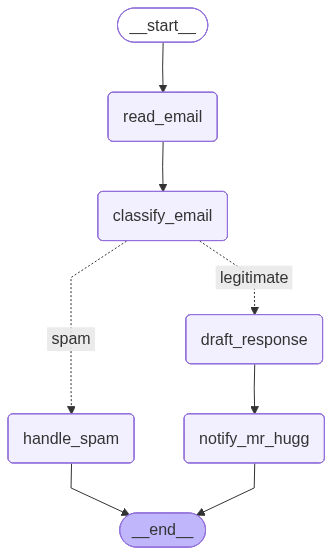

In [14]:
compiled_graph

Notice how we use the special `END` node provided by LangGraph. This indicates terminal states where the workflow completes.

## Step 5: Run the Application

Let's test our graph with a legitimate email and a spam email:

In [15]:
# Example legitimate email
legitimate_email = {
    "sender": "john.smith@example.com",
    "subject": "Question about your services",
    "body": "Dear Mr. Hugg, I was referred to you by a colleague and I'm interested in learning more about your consulting services. Could we schedule a call next week? Best regards, John Smith"
}

# Example spam email
spam_email = {
    "sender": "winner@lottery-intl.com",
    "subject": "YOU HAVE WON $5,000,000!!!",
    "body": "CONGRATULATIONS! You have been selected as the winner of our international lottery! To claim your $5,000,000 prize, please send us your bank details and a processing fee of $100."
}

# Process the legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke({
    "email": legitimate_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})

# Process the spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke({
    "email": spam_email,
    "is_spam": None,
    "spam_reason": None,
    "email_category": None,
    "email_draft": None,
    "messages": []
})


Processing legitimate email...
Alfred is processing an email from john.smith@example.com with subject: Question about your services

Sir, you've received an email from john.smith@example.com.
Subject: Question about your services
Category: inquiry

I've prepared a draft response for your review:
--------------------------------------------------
**DRAFT EMAIL - FOR MR. HUGG'S REVIEW**

---

**To:** john.smith@example.com  
**From:** [Mr. Hugg's email]  
**Subject:** Re: Question about your services

Dear Mr. Smith,

Thank you for your inquiry regarding Mr. Hugg's consulting services. We appreciate the referral from your colleague.

Mr. Hugg would be pleased to discuss how his services might assist you. I will coordinate with his schedule to identify suitable times for a call next week and will follow up with you shortly with available options.

In the meantime, please feel free to share any specific areas of focus or particular questions you'd like to address during your conversation,

## Step 6: Inspecting Our Mail Sorting Agent with Langfuse 📡

As Alfred fine-tunes the Mail Sorting Agent, he's growing weary of debugging its runs. Agents, by nature, are unpredictable and difficult to inspect. But since he aims to build the ultimate Spam Detection Agent and deploy it in production, he needs robust traceability for future monitoring and analysis.

To do this, Alfred can use an observability tool such as [Langfuse](https://langfuse.com/) to trace and monitor the agent.

First, we pip install Langfuse and Langchain:

Next, we add the Langfuse API keys and host address as environment variables. You can get your Langfuse credentials by signing up for [Langfuse Cloud](https://cloud.langfuse.com) or [self-host Langfuse](https://langfuse.com/self-hosting).

In [18]:
!pip install langfuse langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langfuse]1/2 [langfuse]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [19]:
import os
from dotenv import load_dotenv
from huggingface_hub import login, whoami
import os
import base64

load_dotenv(dotenv_path="../.env", override=True)
LANGFUSE_SECRET_KEY = os.environ.get("LANGFUSE_SECRET_KEY")
LANGFUSE_PUBLIC_KEY = os.environ.get("LANGFUSE_PUBLIC_KEY")
os.environ["LANGFUSE_HOST"] = "https://cloud.langfuse.com"  # 🇪🇺 EU region
# os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com"  # 🇺🇸 US region


In [20]:
from langfuse.langchain import CallbackHandler

# Initialize Langfuse CallbackHandler for LangGraph/Langchain (tracing)
langfuse_handler = CallbackHandler()

In [21]:
# Process legitimate email
print("\nProcessing legitimate email...")
legitimate_result = compiled_graph.invoke(
    input={"email": legitimate_email, 
           "is_spam": None, 
           "spam_reason": None, 
           "email_category": None, 
           "draft_response": None, "messages": []},
    config={"callbacks": [langfuse_handler]}
)

# Process spam email
print("\nProcessing spam email...")
spam_result = compiled_graph.invoke(
    input={
        "email": spam_email,
        "is_spam": None,
        "draft_response": None,
        "messages": []
    },
    config={"callbacks": [langfuse_handler]}
)


Processing legitimate email...
Alfred is processing an email from john.smith@example.com with subject: Question about your services

Sir, you've received an email from john.smith@example.com.
Subject: Question about your services
Category: inquiry

I've prepared a draft response for your review:
--------------------------------------------------
**DRAFT EMAIL - FOR MR. HUGG'S REVIEW**

---

**To:** john.smith@example.com  
**From:** [Mr. Hugg's email]  
**Subject:** Re: Question about your services

Dear Mr. Smith,

Thank you for your inquiry regarding Mr. Hugg's consulting services. We appreciate the referral from your colleague.

Mr. Hugg would be pleased to discuss how his services might assist you. I will coordinate with his schedule to identify suitable times for a call next week and will follow up with you shortly with available options.

In the meantime, please feel free to share any specific areas of focus or preliminary questions you may have, as this will help ensure the con

Alfred is now connected 🔌! The runs from LangGraph are being logged in Langfuse, giving him full visibility into the agent's behavior. With this setup, he's ready to revisit previous runs and refine his Mail Sorting Agent even further.

## What We've Built

We've created a complete email processing workflow that:

1. Takes an incoming email
2. Uses an LLM to classify it as spam or legitimate
3. Handles spam by discarding it
4. For legitimate emails, drafts a response and notifies Mr. Hugg

## Key Takeaways

- **State Management**: We defined comprehensive state to track all aspects of email processing
- **Node Implementation**: We created functional nodes that interact with an LLM
- **Conditional Routing**: We implemented branching logic based on email classification
- **Terminal States**: We used the END node to mark completion points in our workflow

## What's Next?

In the next section, we'll explore more advanced features of LangGraph, including handling human interaction in the workflow and implementing more complex branching logic based on multiple conditions.